<a href="https://colab.research.google.com/github/venkatalaxmisamhita/ML_PROJECT12/blob/main/EDA_Report.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")


In [3]:
batting_df = pd.read_csv('/content/bat.csv')
bowling_df = pd.read_csv('/content/ball.csv')
match_df = pd.read_csv('/content/match.csv')


In [4]:
print("==============================================")
print("BATTING DATASET")
print("==============================================")

print("\nFIRST 5 ROWS")
print(batting_df.head())

print("\nDATASET SHAPE")
print(batting_df.shape)

print("\nCOLUMN NAMES")
print(batting_df.columns.tolist())

print("\nDATA TYPES")
print(batting_df.dtypes)

print("\nDATASET INFORMATION")
batting_df.info()

print("\nSTATISTICAL SUMMARY")
print(batting_df.describe())


BATTING DATASET

FIRST 5 ROWS
   Unnamed: 0            name_x playing_role     id  order  runs_x  balls  \
0       13463     Tapash Baisya          NaN  13464      9       7      5   
1       13462     Khaled Mahmud          NaN  13463      8      21     17   
2       13459       Rajin Saleh          NaN  13460      5      14     28   
3       13461  Mushfiqur Rahman          NaN  13462      7       2      6   
4       13458       Aftab Ahmed          NaN  13459      4      30     49   

   strike_rate  fours  sixes  ... matchtype  series_id  match_detail_id  \
0       140.00      1      0  ...       odi        182              773   
1       123.52      3      0  ...       odi        182              773   
2        50.00      1      0  ...       odi        182              773   
3        33.33      0      0  ...       odi        182              773   
4        61.22      2      1  ...       odi        182              773   

                title  runs_y  over run_rate match_id op


MISSING VALUES - BATTING DATASET
Unnamed: 0                 0
name_x                     0
playing_role            1543
id                         0
order                      0
runs_x                     0
balls                      0
strike_rate                0
fours                      0
sixes                      0
how_out                    9
fall_of_wicket         52448
fall_of_wicket_over        0
player_id                  0
scorecard_id               0
match_number             635
name_y                    13
start_date                 0
matchtype                 37
series_id                  0
match_detail_id            0
title                      0
runs_y                     0
over                       0
run_rate                   0
match_id                   0
opp_team_id                0
team_id                    0
dtype: int64


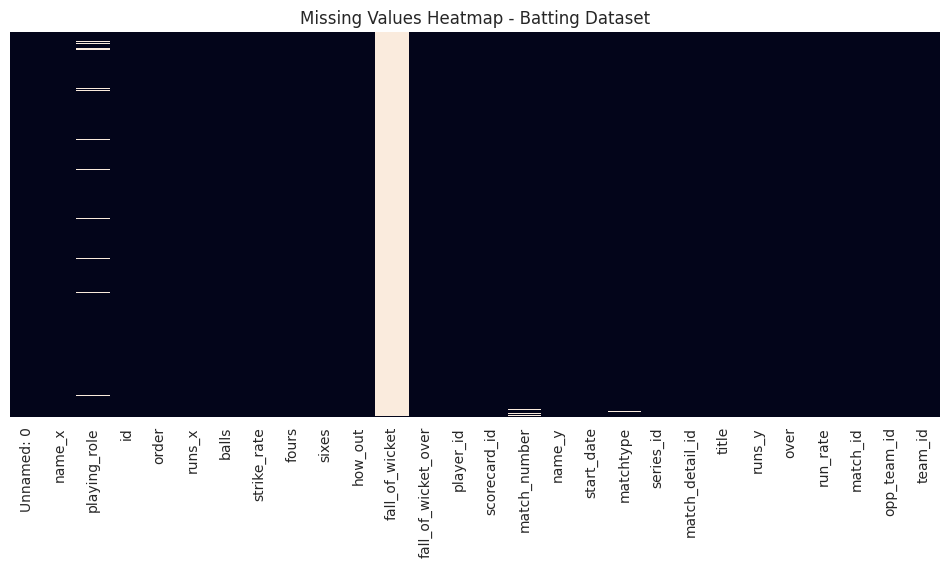

In [5]:
print("\n==============================================")
print("MISSING VALUES - BATTING DATASET")
print("==============================================")

print(batting_df.isnull().sum())

plt.figure(figsize=(12, 5))

sns.heatmap(
    batting_df.isnull(),
    cbar=False,
    yticklabels=False
)

plt.title("Missing Values Heatmap - Batting Dataset")
plt.show()

In [6]:
print("\nDUPLICATE ROWS")

print(batting_df.duplicated().sum())



DUPLICATE ROWS
0



PLAYER PERFORMANCE - RUNS

RUNS STATISTICS
count    52492.000000
mean        22.751353
std         27.865737
min          0.000000
25%          4.000000
50%         13.000000
75%         32.000000
max        329.000000
Name: runs_x, dtype: float64


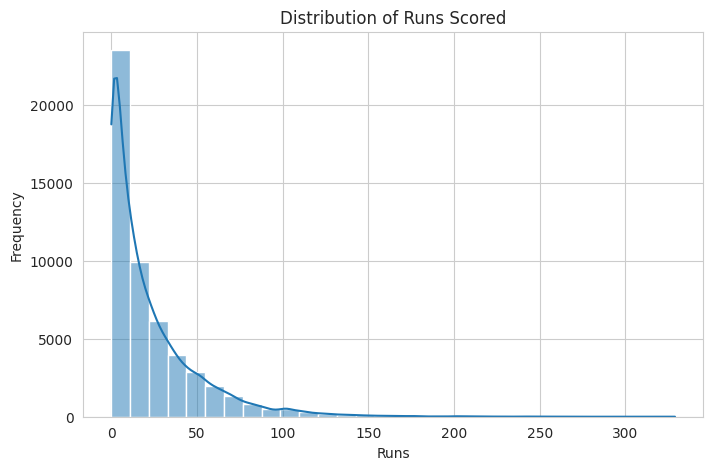

In [7]:
print("\n==============================================")
print("PLAYER PERFORMANCE - RUNS")
print("==============================================")

print("\nRUNS STATISTICS")

print(batting_df['runs_x'].describe())


plt.figure(figsize=(8, 5))

sns.histplot(
    batting_df['runs_x'],
    bins=30,
    kde=True
)

plt.title("Distribution of Runs Scored")
plt.xlabel("Runs")
plt.ylabel("Frequency")

plt.show()


In [8]:

features = [
    'runs_x',
    'balls',
    'strike_rate',
    'fours',
    'sixes'
]



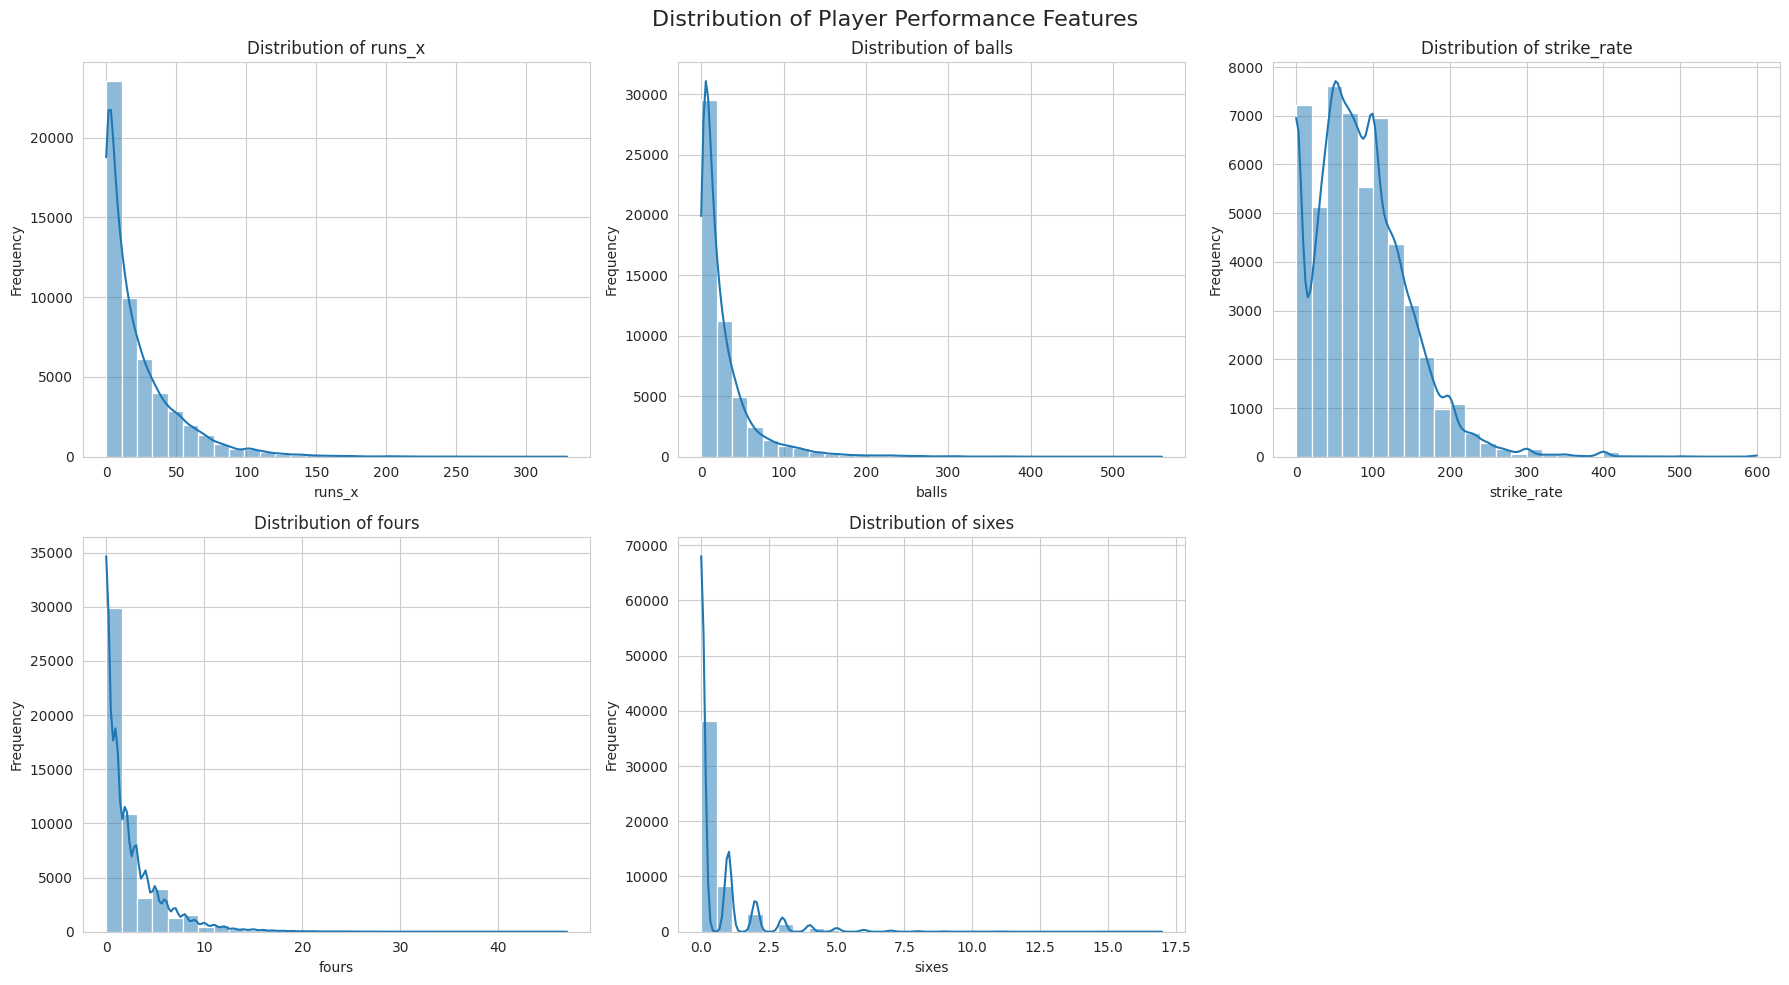

In [9]:
fig, axes = plt.subplots(
    2,
    3,
    figsize=(18, 10)
)

for i, feature in enumerate(features):

    row, col = divmod(i, 3)

    sns.histplot(
        batting_df[feature],
        bins=30,
        kde=True,
        ax=axes[row, col]
    )

    axes[row, col].set_title(
        f"Distribution of {feature}"
    )

    axes[row, col].set_xlabel(feature)
    axes[row, col].set_ylabel("Frequency")


# Hide unused subplot
axes[1, 2].axis("off")


plt.suptitle(
    "Distribution of Player Performance Features",
    fontsize=16
)

plt.tight_layout()
plt.show()

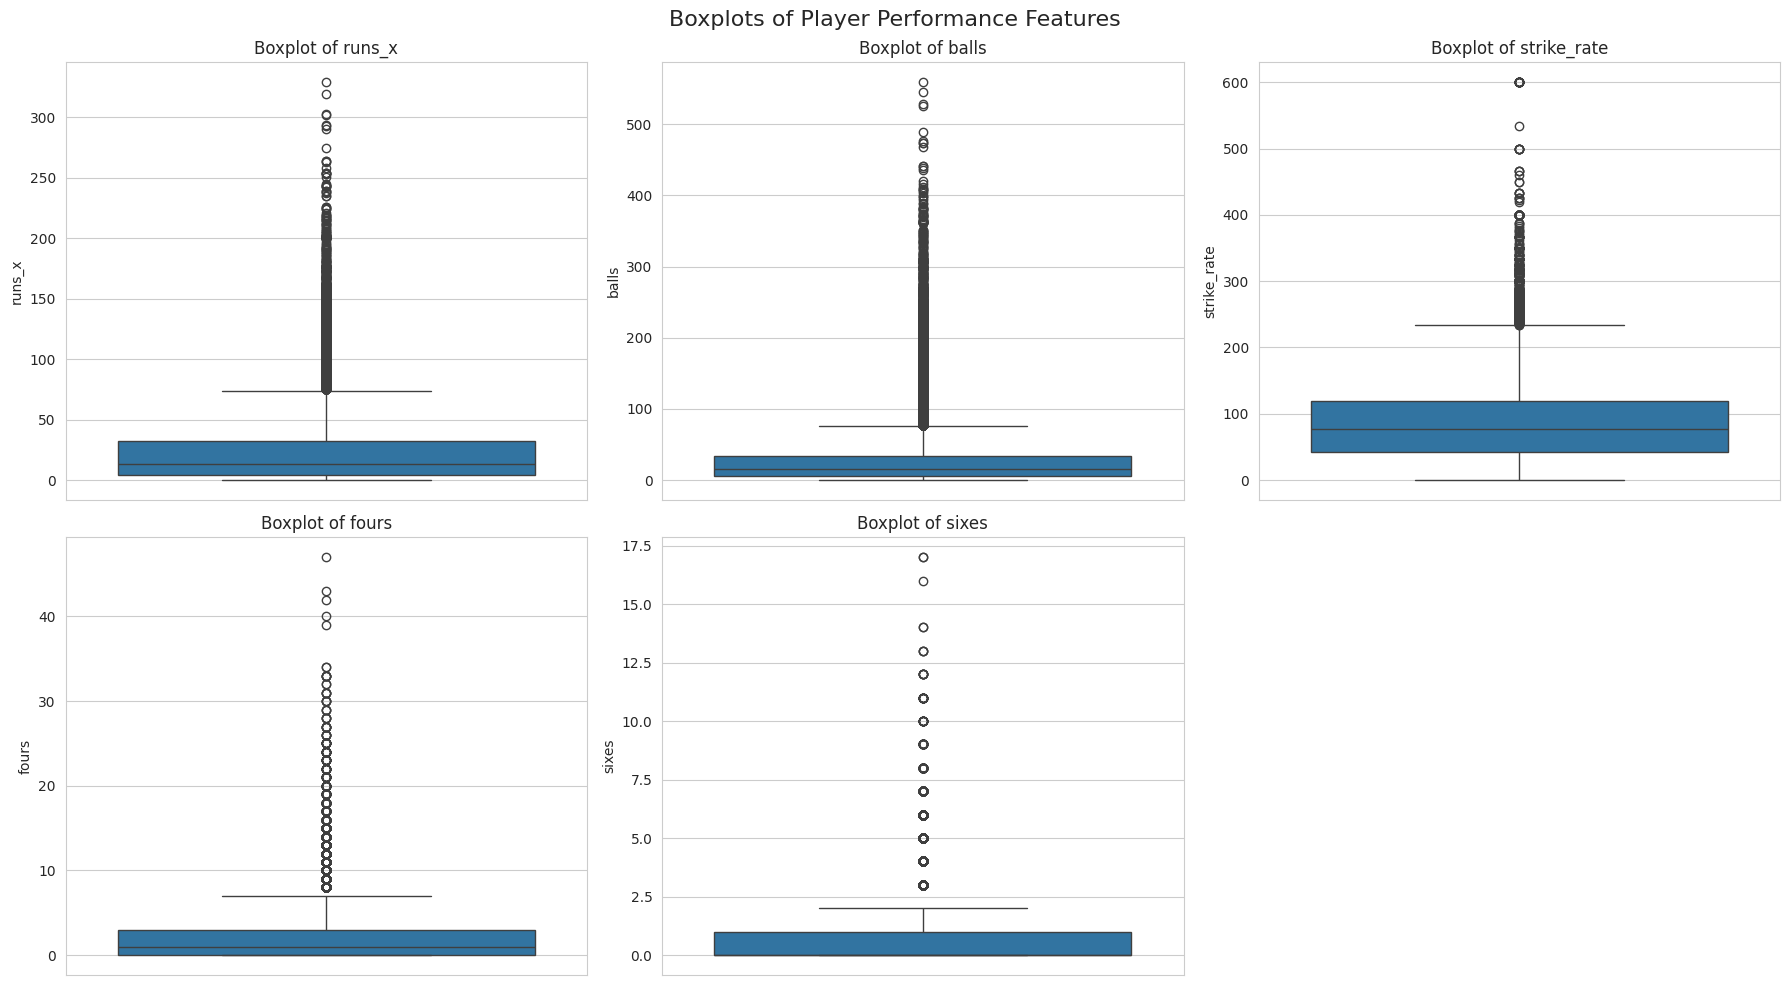

In [10]:
fig, axes = plt.subplots(
    2,
    3,
    figsize=(18, 10)
)

for i, feature in enumerate(features):

    row, col = divmod(i, 3)

    sns.boxplot(
        y=batting_df[feature],
        ax=axes[row, col]
    )

    axes[row, col].set_title(
        f"Boxplot of {feature}"
    )

    axes[row, col].set_ylabel(feature)


axes[1, 2].axis("off")


plt.suptitle(
    "Boxplots of Player Performance Features",
    fontsize=16
)

plt.tight_layout()
plt.show()

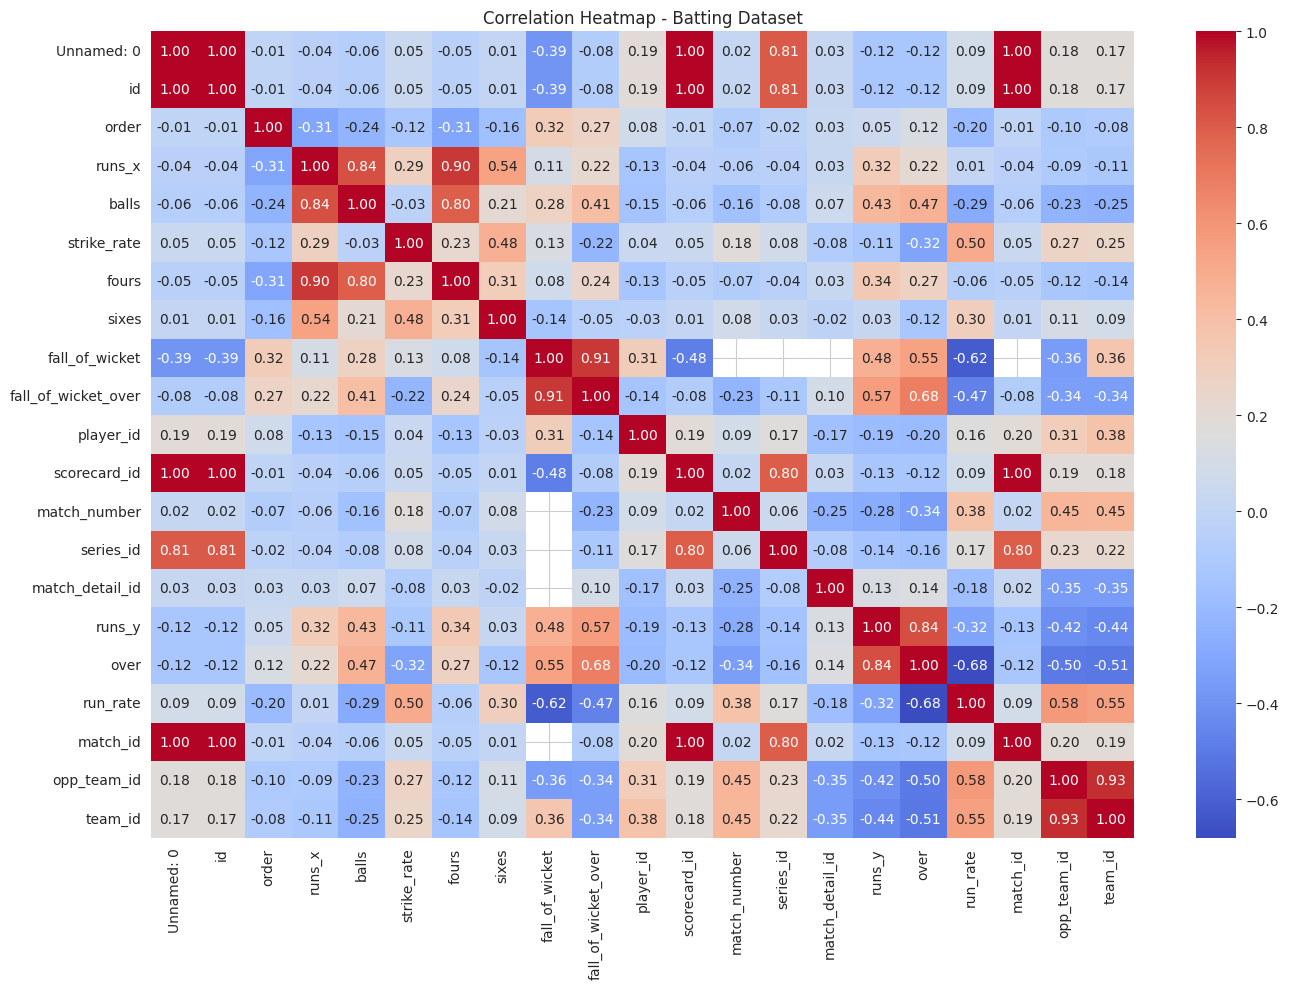

In [11]:
correlation = batting_df.corr(
    numeric_only=True
)


plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title(
    "Correlation Heatmap - Batting Dataset"
)

plt.tight_layout()

plt.show()

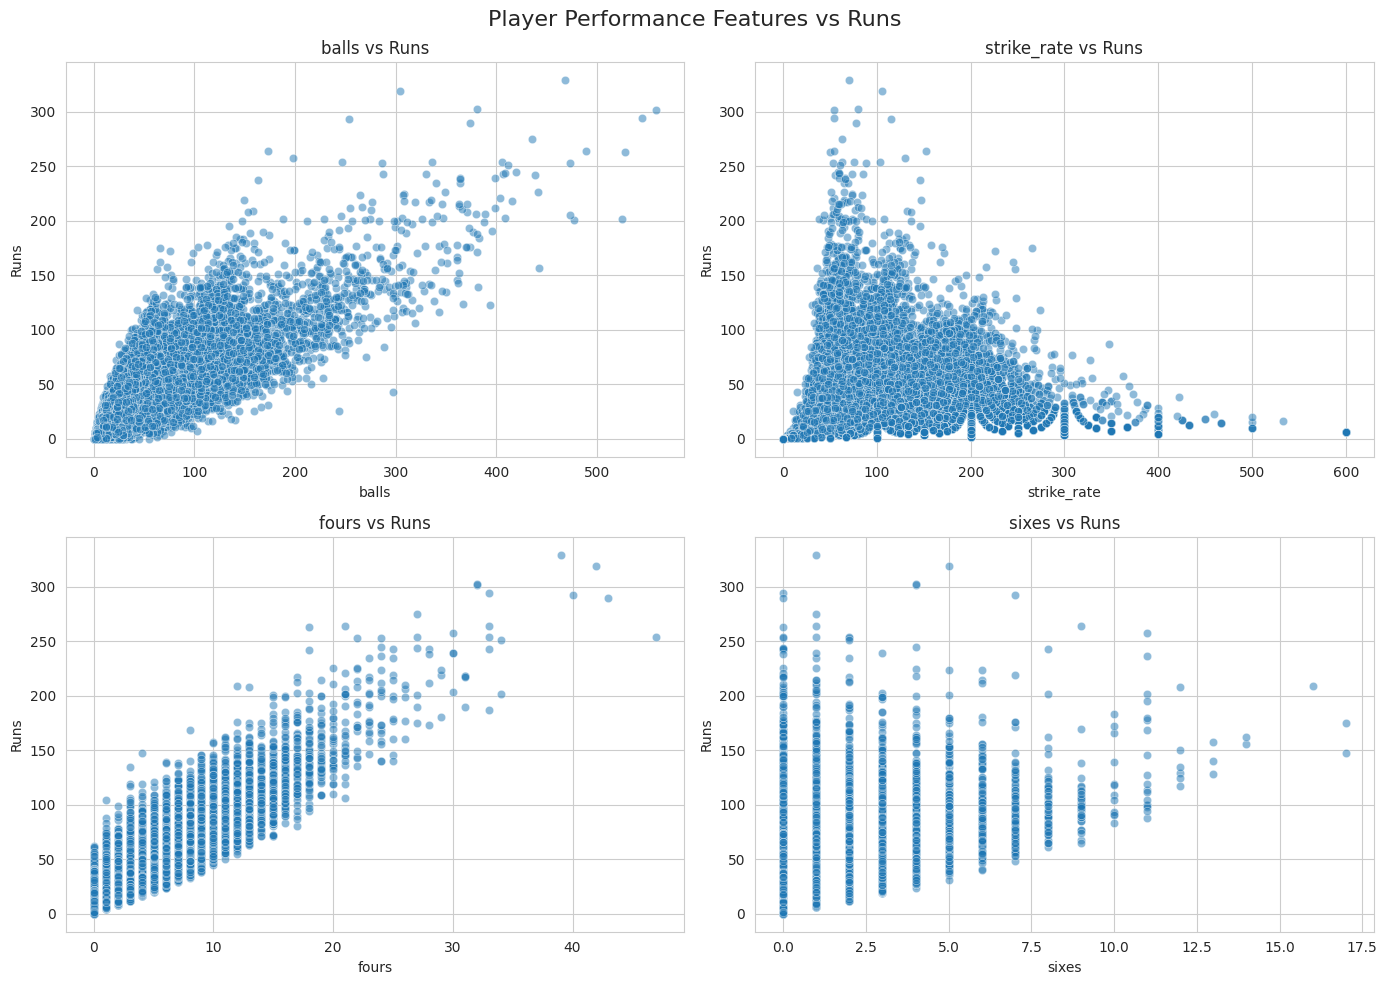

In [12]:
features_vs_target = [
    'balls',
    'strike_rate',
    'fours',
    'sixes'
]


fig, axes = plt.subplots(
    2,
    2,
    figsize=(14, 10)
)

for i, feature in enumerate(features_vs_target):

    row, col = divmod(i, 2)

    sns.scatterplot(
        x=batting_df[feature],
        y=batting_df['runs_x'],
        alpha=0.5,
        ax=axes[row, col]
    )

    axes[row, col].set_title(
        f"{feature} vs Runs"
    )

    axes[row, col].set_xlabel(feature)
    axes[row, col].set_ylabel("Runs")


plt.suptitle(
    "Player Performance Features vs Runs",
    fontsize=16
)

plt.tight_layout()

plt.show()



TOP 10 RUN SCORERS
name_x
Virat Kohli        28069
MS Dhoni           21865
Rohit Sharma       19117
David Warner       14660
Shikhar Dhawan     14580
AB de Villiers     13868
Ross Taylor        13755
Joe Root           13453
Kane Williamson    13122
Gautam Gambhir     13062
Name: runs_x, dtype: int64


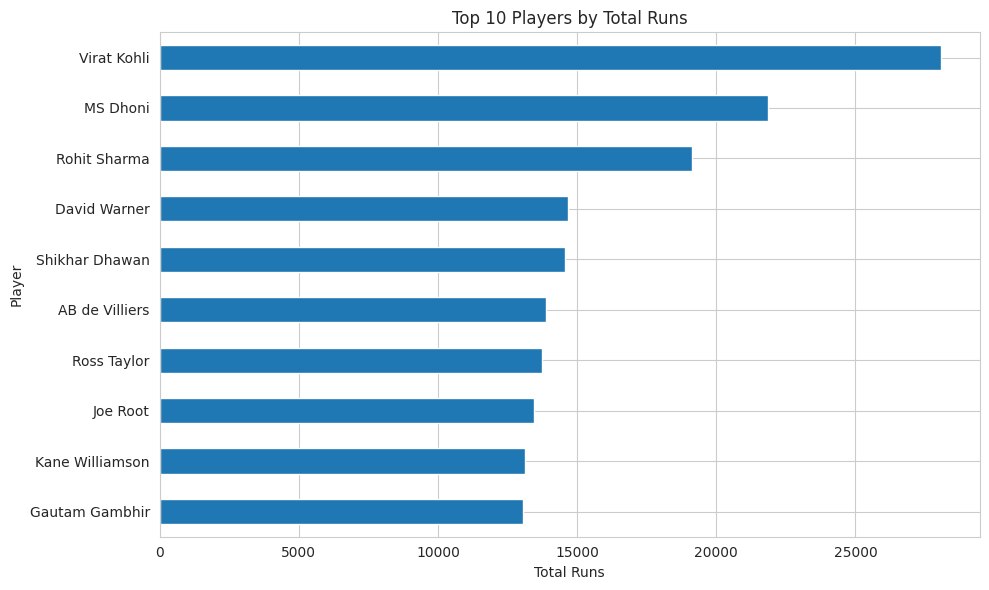

In [13]:
print("\n==============================================")
print("TOP 10 RUN SCORERS")
print("==============================================")


top_run_scorers = (
    batting_df
    .groupby('name_x')['runs_x']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)


print(top_run_scorers)


plt.figure(figsize=(10, 6))

top_run_scorers.sort_values().plot(
    kind='barh'
)

plt.title(
    "Top 10 Players by Total Runs"
)

plt.xlabel("Total Runs")
plt.ylabel("Player")

plt.tight_layout()

plt.show()

In [14]:
print("\n==============================================")
print("BOWLING DATASET")
print("==============================================")


print("\nFIRST 5 ROWS")

print(bowling_df.head())


print("\nDATASET SHAPE")

print(bowling_df.shape)


print("\nCOLUMN NAMES")

print(bowling_df.columns.tolist())


print("\nDATA TYPES")

print(bowling_df.dtypes)


print("\nSTATISTICAL SUMMARY")

print(bowling_df.describe())



BOWLING DATASET

FIRST 5 ROWS
   Unnamed: 0            name_x playing_role    id  order  run_conceded  \
0        8526      Ajit Agarkar         BOWL  8544      2            51   
1        8518     Tapash Baisya          NaN  8536      0            67   
2        8519  Mushfiqur Rahman          NaN  8537      1            29   
3        8520    Nazmul Hossain         BOWL  8538      2            39   
4        8521     Khaled Mahmud          NaN  8539      3            43   

   maidens  wickets  overs  economy  ...  matchtype  series_id  \
0        0        2   10.0     5.10  ...        odi        182   
1        0        2   10.0     6.70  ...        odi        182   
2        0        1    6.0     4.83  ...        odi        182   
3        1        2    9.0     4.33  ...        odi        182   
4        0        1   10.0     4.30  ...        odi        182   

   match_detail_id               title  runs  over  run_rate  match_id  \
0              773  Bangladesh Innings   234  5


BOWLING MISSING VALUES
Unnamed: 0             0
name_x                 0
playing_role        1257
id                     0
order                  0
run_conceded           0
maidens                0
wickets                0
overs                  0
economy                0
wides                  0
no_balls               0
fours              36134
sixes              36134
zeros              36134
player_id              0
scorecard_id           0
match_number         436
name_y                12
start_date             0
matchtype             16
series_id              0
match_detail_id        0
title                  0
runs                   0
over                   0
run_rate               0
match_id               0
opp_team_id            0
team_id                0
dtype: int64


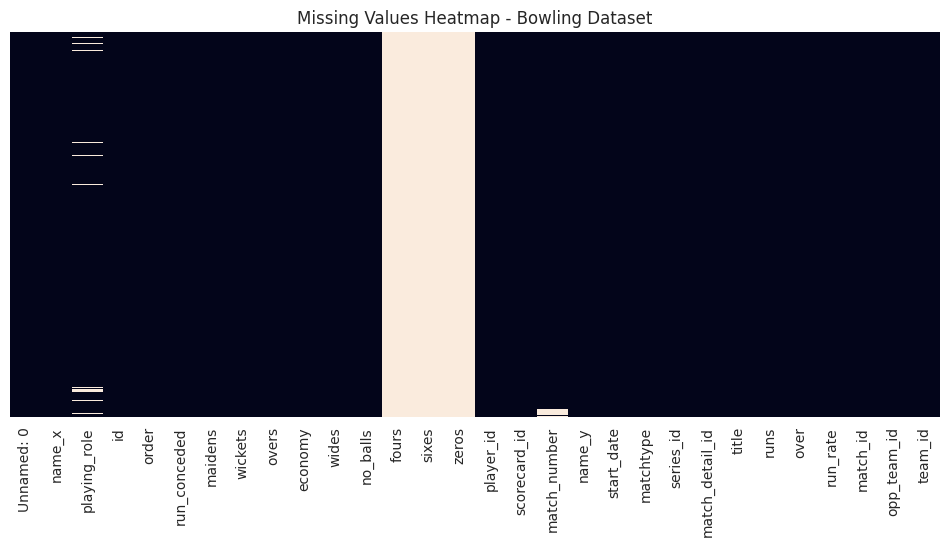

In [15]:
print("\nBOWLING MISSING VALUES")

print(bowling_df.isnull().sum())


plt.figure(figsize=(12, 5))

sns.heatmap(
    bowling_df.isnull(),
    cbar=False,
    yticklabels=False
)

plt.title(
    "Missing Values Heatmap - Bowling Dataset"
)

plt.show()


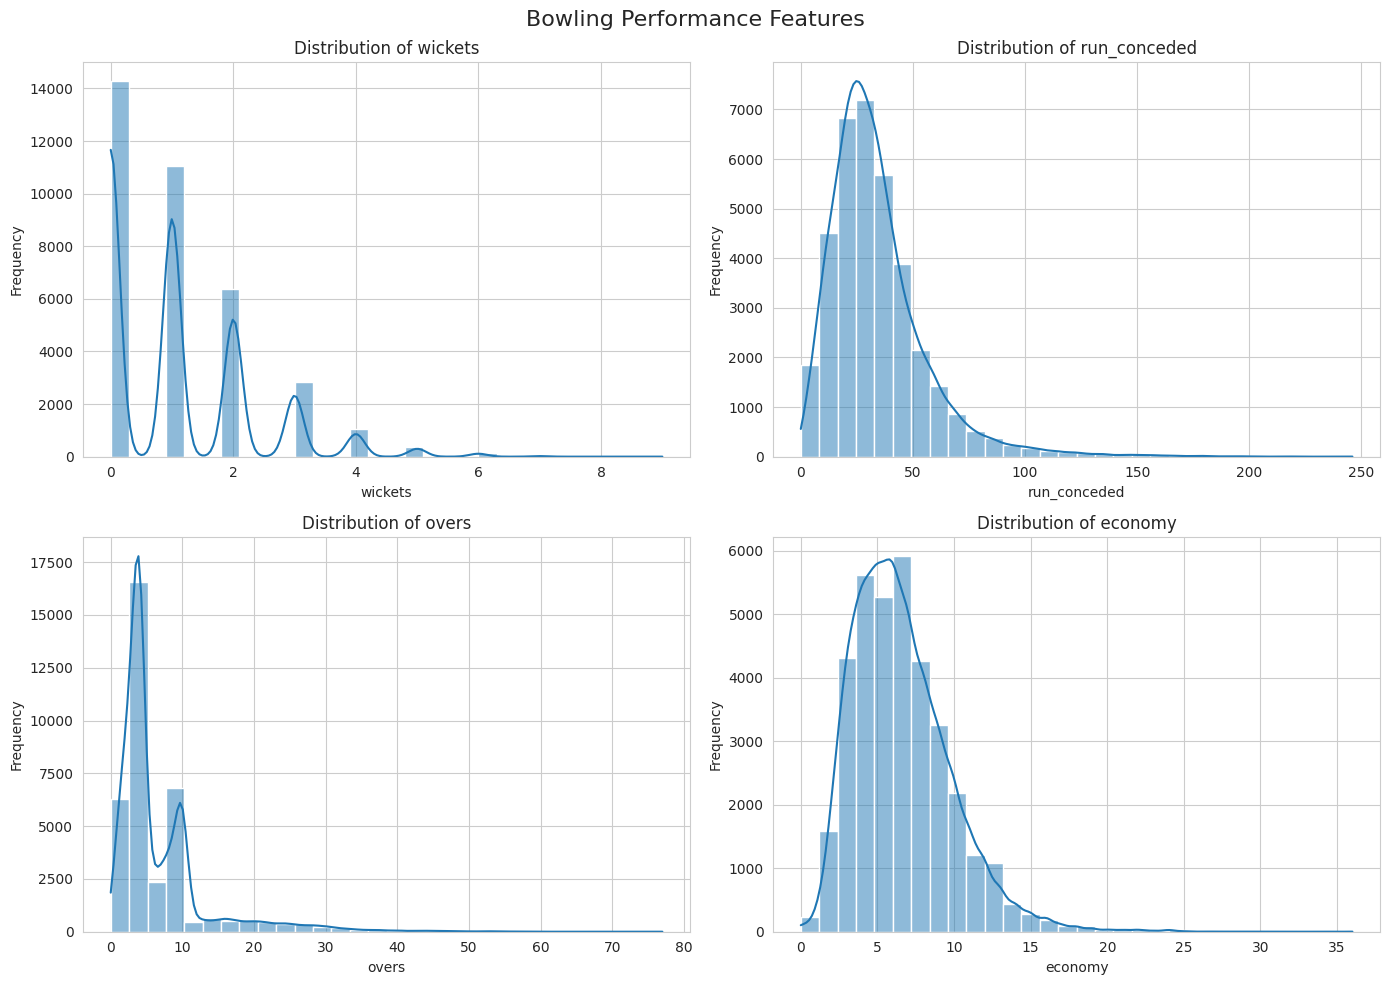

In [17]:
bowling_features = [
    'wickets',
    'run_conceded',
    'overs',
    'economy'
]


fig, axes = plt.subplots(
    2,
    2,
    figsize=(14, 10)
)


for i, feature in enumerate(bowling_features):

    row, col = divmod(i, 2)

    sns.histplot(
        bowling_df[feature],
        bins=30,
        kde=True,
        ax=axes[row, col]
    )

    axes[row, col].set_title(
        f"Distribution of {feature}"
    )

    axes[row, col].set_xlabel(feature)
    axes[row, col].set_ylabel("Frequency")


plt.suptitle(
    "Bowling Performance Features",
    fontsize=16
)

plt.tight_layout()

plt.show()


TOP 10 WICKET TAKERS
name_x
Ravichandran Ashwin    712
Tim Southee            596
Ravindra Jadeja        543
James Anderson         528
Harbhajan Singh        513
Stuart Broad           501
Ishant Sharma          467
Trent Boult            465
Zaheer Khan            439
Mohammed Shami         400
Name: wickets, dtype: int64


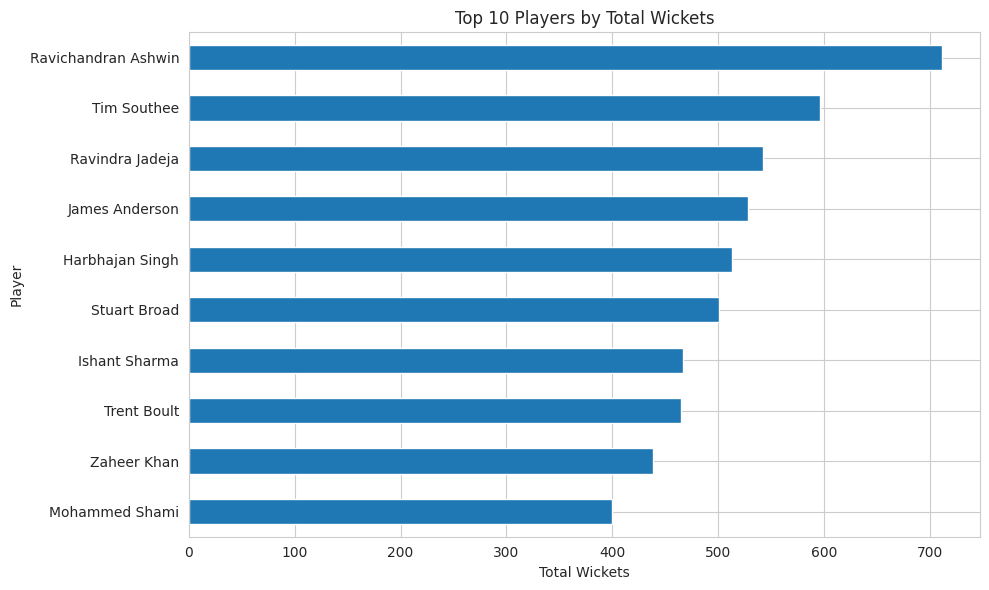

In [18]:
print("\n==============================================")
print("TOP 10 WICKET TAKERS")
print("==============================================")


top_wicket_takers = (
    bowling_df
    .groupby('name_x')['wickets']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)


print(top_wicket_takers)


plt.figure(figsize=(10, 6))

top_wicket_takers.sort_values().plot(
    kind='barh'
)

plt.title(
    "Top 10 Players by Total Wickets"
)

plt.xlabel("Total Wickets")
plt.ylabel("Player")

plt.tight_layout()

plt.show()


In [19]:
print("\n==============================================")
print("MATCH DATASET")
print("==============================================")


print("\nFIRST 5 ROWS")

print(match_df.head())


print("\nDATASET SHAPE")

print(match_df.shape)


print("\nCOLUMN NAMES")

print(match_df.columns.tolist())


print("\nDATA TYPES")

print(match_df.dtypes)


print("\nSTATISTICAL SUMMARY")

print(match_df.describe())



MATCH DATASET

FIRST 5 ROWS
   Unnamed: 0  match_number                name                 start_date  \
0        1417           1.0  Bangladesh v India  2004-12-22 18:30:00+00:00   
1        1418           1.0  Bangladesh v India  2004-12-22 18:30:00+00:00   
2        1419           2.0  Bangladesh v India  2004-12-25 18:30:00+00:00   
3        1420           2.0  Bangladesh v India  2004-12-25 18:30:00+00:00   
4        1421           3.0  Bangladesh v India  2004-12-26 18:30:00+00:00   

  matchtype  series_id  match_detail_id  scorecard_id               title  \
0       odi        182              773          1495       India Innings   
1       odi        182              773          1496  Bangladesh Innings   
2       odi        182              774          1497  Bangladesh Innings   
3       odi        182              774          1498       India Innings   
4       odi        182              775          1499       India Innings   

   runs  over  run_rate  match_id  opp_

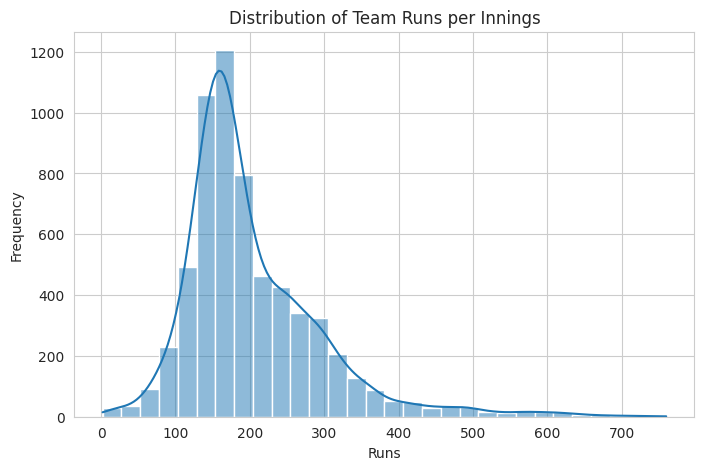

In [20]:
plt.figure(figsize=(8, 5))

sns.histplot(
    match_df['runs'],
    bins=30,
    kde=True
)

plt.title(
    "Distribution of Team Runs per Innings"
)

plt.xlabel("Runs")
plt.ylabel("Frequency")

plt.show()


In [21]:
print("\n==============================================")
print("IMPORTANT CORRELATIONS WITH RUNS")
print("==============================================")


runs_correlation = (
    batting_df
    .corr(numeric_only=True)['runs_x']
    .sort_values(ascending=False)
)


print(runs_correlation)


IMPORTANT CORRELATIONS WITH RUNS
runs_x                 1.000000
fours                  0.902379
balls                  0.841776
sixes                  0.544621
runs_y                 0.322473
strike_rate            0.290559
fall_of_wicket_over    0.221582
over                   0.216307
fall_of_wicket         0.108756
match_detail_id        0.032506
run_rate               0.009995
series_id             -0.038830
id                    -0.040746
Unnamed: 0            -0.040781
scorecard_id          -0.041428
match_id              -0.043260
match_number          -0.056152
opp_team_id           -0.089866
team_id               -0.109700
player_id             -0.133616
order                 -0.310913
Name: runs_x, dtype: float64


In [22]:
print("\n==============================================")
print("EDA SUMMARY")
print("==============================================")

print("\nBatting Dataset Shape:", batting_df.shape)

print("Bowling Dataset Shape:", bowling_df.shape)

print("Match Dataset Shape:", match_df.shape)

print("\nTotal Missing Values:")
print("Batting:", batting_df.isnull().sum().sum())
print("Bowling:", bowling_df.isnull().sum().sum())
print("Match:", match_df.isnull().sum().sum())

print("\nDuplicate Rows:")
print("Batting:", batting_df.duplicated().sum())
print("Bowling:", bowling_df.duplicated().sum())
print("Match:", match_df.duplicated().sum())


print("\nEDA COMPLETED SUCCESSFULLY!")


EDA SUMMARY

Batting Dataset Shape: (52492, 28)
Bowling Dataset Shape: (36149, 30)
Match Dataset Shape: (6199, 15)

Total Missing Values:
Batting: 54685
Bowling: 110123
Match: 81

Duplicate Rows:
Batting: 0
Bowling: 0
Match: 0

EDA COMPLETED SUCCESSFULLY!
